In [18]:
!pip install plotly nbformat

     ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.9 MB 2.0 MB/s eta 0:00:05
     ---------------------------------------- 0.1/9.9 MB 1.7 MB/s eta 0:00:06
      --------------------------------------- 0.2/9.9 MB 1.8 MB/s eta 0:00:06
     - -------------------------------------- 0.3/9.9 MB 1.5 MB/s eta 0:00:07
     - -------------------------------------- 0.4/9.9 MB 1.7 MB/s eta 0:00:06
     - -------------------------------------- 0.5/9.9 MB 1.8 MB/s eta 0:00:06
     -- ------------------------------------- 0.6/9.9 MB 2.1 MB/s eta 0:00:05
     --- ------------------------------------ 0.8/9.9 MB 2.3 MB/s eta 0:00:05
     --- ------------------------------------ 1.0/9.9 MB 2.3 MB/s eta 0:00:04
     ---- ----------------------------------- 1.2/9.9 MB 2.5 MB/s eta 0:00:04
     ----- ---------------------------------- 1.3/9.9 MB 2.6 MB/s eta 0:00:04
     ------ --------------------------------- 1.5/9.9 MB 2.6 MB/s eta 0


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# SecurePay – Real-Time Fraud Detection using Unsupervised Learning

## Case Study: FinTech Fraud Detection System

Fraud detection in financial transactions is a critical challenge due to extreme class imbalance. This project implements an unsupervised anomaly detection system using Isolation Forest and Local Outlier Factor (LOF) to detect fraudulent transactions in real-time.

## Data Loading

In [2]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analysis

### Class Imbalance
Fraud transactions are extremely rare (~0.8%), making supervised models ineffective.

In [3]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

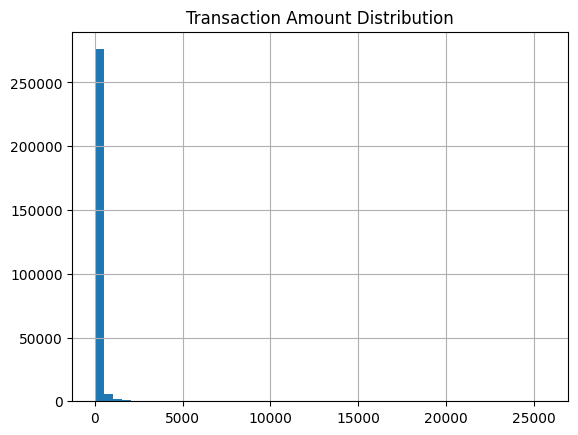

In [5]:
import matplotlib.pyplot as plt

df['Amount'].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

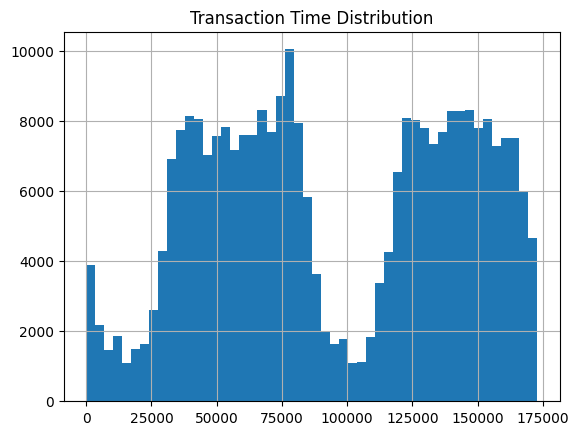

In [6]:
df['Time'].hist(bins=50)
plt.title("Transaction Time Distribution")
plt.show()

## Feature Engineering

- Log transformation applied to Amount
- Hour extracted from Time feature

In [7]:
import numpy as np

df['Amount_log'] = np.log1p(df['Amount'])
df['Hour'] = (df['Time'] // 3600) % 24

## Robust Scaling

RobustScaler is used as it is resistant to outliers, unlike StandardScaler.

In [8]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df[['Amount', 'Amount_log', 'Time']] = scaler.fit_transform(df[['Amount', 'Amount_log', 'Time']])

## Training Strategy

Train only on normal transactions to learn baseline behavior.

In [9]:
from sklearn.model_selection import train_test_split

normal_df = df[df['Class'] == 0]
fraud_df = df[df['Class'] == 1]

train_df, test_normal_df = train_test_split(normal_df, test_size=0.2, random_state=42)
test_df = pd.concat([test_normal_df, fraud_df])

 MODEL IMPLEMENTATION
🔹 Isolation Forest1. 

In [10]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.02, n_estimators=300, random_state=42)
iso_model.fit(train_df.drop('Class', axis=1))

iso_scores = -iso_model.decision_function(test_df.drop('Class', axis=1))

🔹 Local Outlier Factor (LOF)

In [11]:
from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(n_neighbors=15, contamination=0.02, novelty=True)
lof_model.fit(train_df.drop('Class', axis=1))

lof_scores = -lof_model.score_samples(test_df.drop('Class', axis=1))

c:\Securepay-fraud-detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


SCORE NORMALIZATION

In [12]:
iso_scores = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())
lof_scores = (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())

test_df['iso_score'] = iso_scores
test_df['lof_score'] = lof_scores

PCA VISUALIZATION

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
iso_model = IsolationForest(contamination=0.01, n_estimators=200, random_state=42)
test_df['iso_pred'] = iso_model.fit_predict(test_df.drop(['Class', 'iso_score', 'lof_score'], axis=1, errors='ignore'))
test_df['iso_pred'] = [1 if x == -1 else 0 for x in test_df['iso_pred']]
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
test_df['lof_pred'] = lof_model.fit_predict(test_df.drop(['Class', 'iso_score', 'lof_score', 'iso_pred'], axis=1, errors='ignore'))
test_df['lof_pred'] = [1 if x == -1 else 0 for x in test_df['lof_pred']]

## PCA Visualization (True Fraud vs Normal Distribution)
To analyze the intrinsic structure of the transaction data, we apply Principal Component Analysis (PCA) to reduce the high-dimensional feature space into two principal components (PC1 and PC2).

In this visualization:
- Each point represents a transaction
- Colors indicate the true class labels:
  - Yellow → Fraudulent transactions
  - Purple → Normal transactions

### Key Observations:
- **Severe Class Imbalance**: The majority of points belong to normal transactions, while fraud cases are extremely sparse.
- **Fraud in Low-Density Regions**: Fraudulent transactions are primarily located near sparse or boundary regions of the distribution rather than dense clusters.
- **Cluster Formation**: Normal transactions form dense vertical clusters, indicating consistent behavioral patterns across transactions.
- **Outlier Nature of Fraud**: Fraud points do not follow the same structured patterns as normal data, reinforcing that fraud behaves as an anomaly.

### Technical Insight:
PCA preserves maximum variance while reducing dimensionality. The fact that fraud points appear scattered and isolated in this reduced space confirms that anomaly detection techniques are suitable for this dataset.

### Business Interpretation:
Since fraudulent transactions deviate significantly from normal transaction patterns, they can be effectively detected using unsupervised anomaly detection models such as Isolation Forest and LOF. This validates the core assumption of our system: **fraud ≠ normal behavior**.

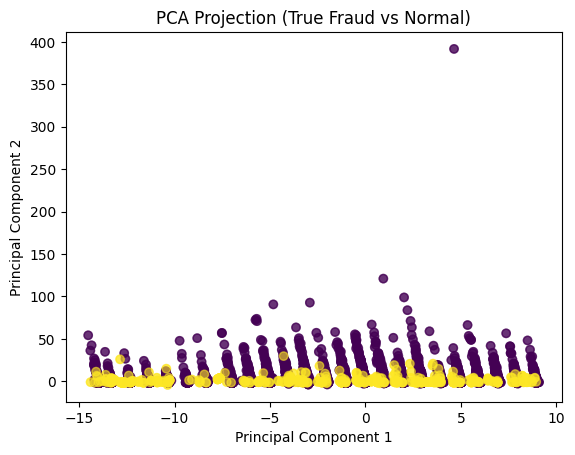

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(test_df.drop(['Class'], axis=1))

plt.scatter(X_pca[:,0], X_pca[:,1], 
            c=test_df['Class'], alpha=0.5)

plt.title("PCA Projection (True Fraud vs Normal)")
plt.scatter(X_pca[:,0], X_pca[:,1], c=test_df['Class'], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## PCA Visualization (Isolation Forest Predictions)

This plot visualizes the anomaly detection results from the Isolation Forest model in a reduced 2D space using PCA.

In this plot:
- Grey points → Normal transactions (predicted)
- Red points → Detected anomalies

### Insights:
- The model identifies anomalies primarily in sparse regions of the feature space.
- Many detected anomalies align with low-density areas observed in the ground truth visualization.
- Isolation Forest effectively isolates outliers by randomly partitioning the feature space.

### Model Behavior:
Isolation Forest works by recursively partitioning data points. Transactions that require fewer splits to isolate are considered anomalous.

### Business Interpretation:
The model is capable of identifying suspicious transactions that deviate from normal patterns, making it suitable for real-time fraud detection.

---------------------------------------------------------

## PCA Visualization (Local Outlier Factor Predictions)

This plot shows anomaly detection using the Local Outlier Factor (LOF) algorithm.

In this plot:
- Grey points → Normal transactions
- Blue points → Detected anomalies

### Insights:
- LOF identifies anomalies based on local density differences.
- Transactions in regions with significantly lower density than their neighbors are flagged as anomalies.
- Compared to Isolation Forest, LOF may detect anomalies more locally rather than globally.

### Model Behavior:
LOF compares the density of each point with that of its neighbors. Points with lower relative density are considered anomalies.

### Business Interpretation:
LOF is effective for detecting localized fraud patterns but may be computationally expensive for large-scale real-time systems.

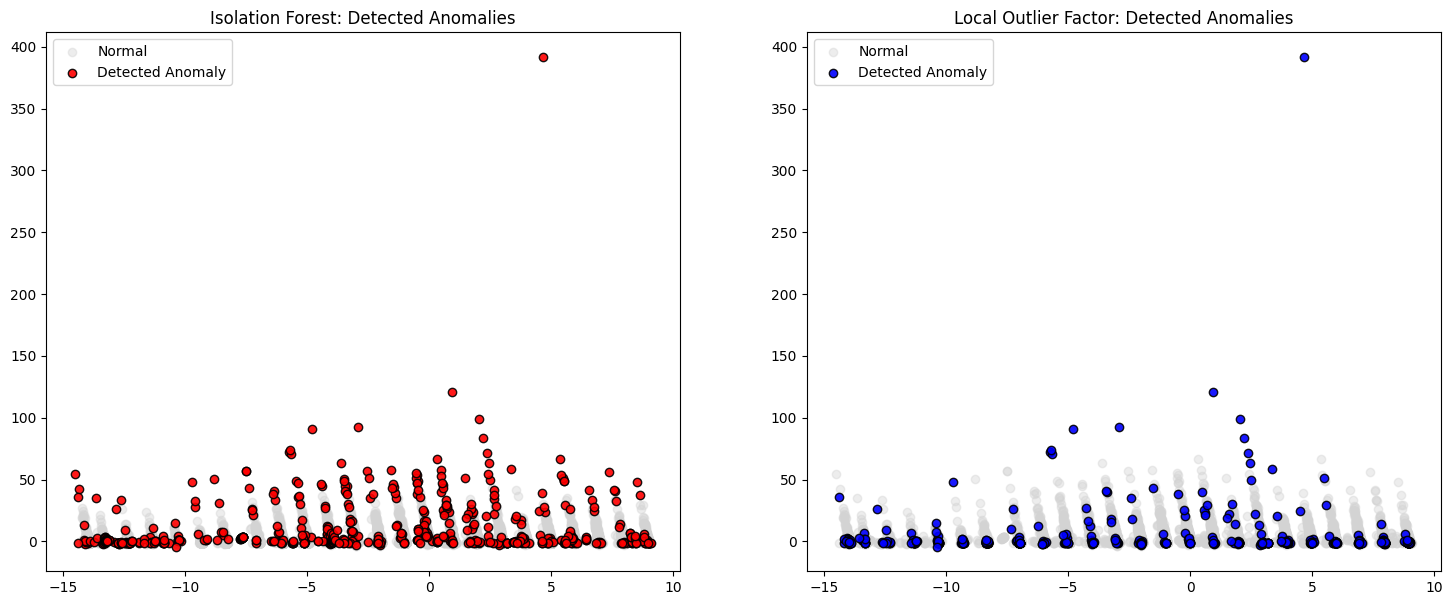

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ax1.scatter(X_test_pca[test_df['iso_pred'] == 0, 0], X_test_pca[test_df['iso_pred'] == 0, 1], 
            c='lightgrey', label='Normal', alpha=0.4)
ax1.scatter(X_test_pca[test_df['iso_pred'] == 1, 0], X_test_pca[test_df['iso_pred'] == 1, 1], 
            c='red', label='Detected Anomaly', alpha=0.9, edgecolors='k')
ax1.set_title("Isolation Forest: Detected Anomalies")
ax1.legend()
ax2.scatter(X_test_pca[test_df['lof_pred'] == 0, 0], X_test_pca[test_df['lof_pred'] == 0, 1], 
            c='lightgrey', label='Normal', alpha=0.4)
ax2.scatter(X_test_pca[test_df['lof_pred'] == 1, 0], X_test_pca[test_df['lof_pred'] == 1, 1], 
            c='blue', label='Detected Anomaly', alpha=0.9, edgecolors='k')
ax2.set_title("Local Outlier Factor: Detected Anomalies")
ax2.legend()

plt.show()

## 3D PCA Visualization (Isolation Forest Anomaly Detection)

To better capture complex relationships in the data, PCA is extended to 3 dimensions.

In this interactive plot:
- Each point represents a transaction
- Red points indicate detected anomalies
- Grey points represent normal transactions

### Insights:
- The 3D representation provides a clearer separation of anomalies in certain regions.
- Some anomalies become more distinguishable when additional dimensions are considered.
- Clusters of normal transactions remain dense, while anomalies are scattered.

### Technical Advantage:
Higher-dimensional projections can reveal separations that are not visible in 2D, improving interpretability.

### Business Interpretation:
This visualization demonstrates that fraudulent transactions deviate across multiple feature dimensions, reinforcing the need for multidimensional anomaly detection models.

In [19]:
import plotly.express as px
# 3D PCA
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(test_df.drop(['Class', 'iso_pred', 'lof_pred'], axis=1))

fig = px.scatter_3d(x=X_3d[:,0], y=X_3d[:,1], z=X_3d[:,2],
                    color=test_df['iso_pred'].astype(str),
                    title="3D PCA: Isolation Forest Detections",
                    labels={'color': 'Detected Anomaly'},
                    color_discrete_map={'0': 'lightgrey', '1': 'red'})
fig.show()

## Summary of Visual Analysis

Across all visualizations, the following key observations were made:

- Fraudulent transactions consistently appear in low-density regions.
- Isolation Forest effectively captures global anomalies.
- LOF identifies local density-based anomalies.
- PCA projections validate that anomaly detection is a suitable approach for this dataset.

### Final Insight:
The combination of statistical isolation (Isolation Forest) and density-based detection (LOF) provides a strong framework for fraud detection in highly imbalanced financial datasets.

## Threshold Selection using 99th percentile

In [13]:
threshold = test_df['iso_score'].quantile(0.99)
test_df['iso_pred'] = (test_df['iso_score'] > threshold).astype(int)

CONFUSION MATRIX
🔹 Isolation Forest

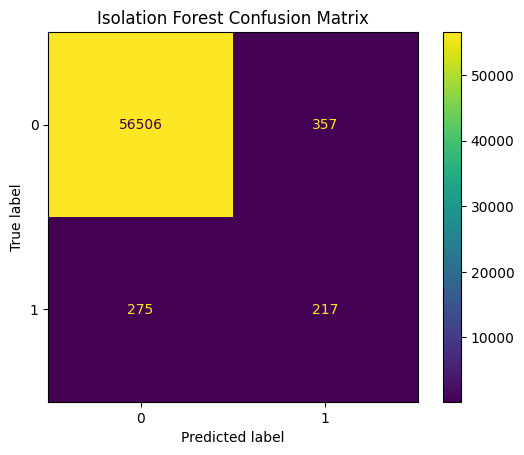

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_df['Class'], test_df['iso_pred'])
ConfusionMatrixDisplay(cm).plot()
plt.title("Isolation Forest Confusion Matrix")
plt.show()

🔹 LOF

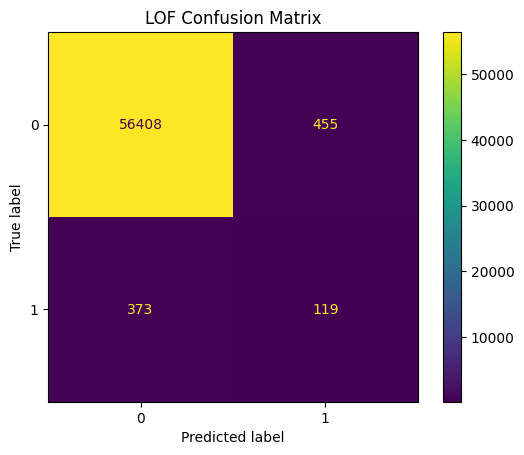

In [15]:
threshold_lof = test_df['lof_score'].quantile(0.99)
test_df['lof_pred'] = (test_df['lof_score'] > threshold_lof).astype(int)

cm_lof = confusion_matrix(test_df['Class'], test_df['lof_pred'])
ConfusionMatrixDisplay(cm_lof).plot()
plt.title("LOF Confusion Matrix")
plt.show()

METRICS

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(test_df['Class'], test_df['iso_pred'])
recall = recall_score(test_df['Class'], test_df['iso_pred'])
f1 = f1_score(test_df['Class'], test_df['iso_pred'])

print("Isolation Forest - Precision: ", precision, "\nRecall: ", recall, "\nF1: ", f1)

Isolation Forest - Precision:  0.3780487804878049 
Recall:  0.4410569105691057 
F1:  0.4071294559099437
